<div dir="rtl" style="text-align: center;">
  <h1 style="color: #9e0059; font-family: B Titr; font-size: 68px;">
    Pandas & Matplotlib
  </h1>
  <h1 style="color: #8660a9; font-family: B Titr; font-size: 40px;">
    داده‌کاوی
  </h1>
  <h1 style="color: #8660a9; font-family: B Titr; font-size: 32px;">
    استاد درس: دکتر رضازادگان | دستیار آموزشی: کیانا آشفته فرد
  </h1>
</div>

<div dir="rtl"><font color="#9e0059" face="B Titr">

# pandas

</div>



<div dir="rtl" style="font-family: 'B Nazanin'; font-size: 20px;">

Pandas یک کتابخانه متن باز در پایتون است که برای کار با داده ها، به ویژه داده های جدولی، طراحی شده و در سال 2010 به صورت متن باز منتشر شد. این کتابخانه ابزارهایی برای خواندن، سازماندهی، پاکسازی، تبدیل و تحلیل داده ها فراهم می کند و به طور گسترده در پروژه های علم داده مورد استفاده قرار می گیرد. همچنین بر پایه NumPy ساخته شده و در کنار کتابخانه هایی مانند NumPy، Matplotlib و Scikit-learn به کار می رود. دو ساختار اصلی داده در آن عبارتند از:

* Series برای داده های یک بعدی
* DataFrame برای داده های دو بعدی و جدولی

همچنین امکانات مختلفی برای مدیریت داده های ناقص، مانند حذف یا جایگزینی مقادیر گمشده، فراهم می کند.


</div>


In [222]:
import pandas as pd
# from pandas import Series, DataFrame

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

<div dir="rtl"><font color="#9e0059" face="B Titr">

## Series

</div>

<div dir="rtl"><font color="#9e0059" face="B Titr">

### نحوه‌ی ساخت

</div>

In [223]:
obj = pd.Series([4, 7, -5, 3])
print(f"""
pd.Series([4, 7, -5, 3]):\n
{obj}\n
values -> {obj.values}
index -> {obj.index}
""")

data_dict = { 'Apple': 225, 'Microsoft': 510, 'Nvidia': 185 } 
ser = pd.Series(data_dict)

print(f"""
pd.Series(data_dict):\n
{ser}\n
values -> {ser.values}
index -> {ser.index}
""")


pd.Series([4, 7, -5, 3]):

0    4
1    7
2   -5
3    3
dtype: int64

values -> [ 4  7 -5  3]
index -> RangeIndex(start=0, stop=4, step=1)


pd.Series(data_dict):

Apple        225
Microsoft    510
Nvidia       185
dtype: int64

values -> [225 510 185]
index -> Index(['Apple', 'Microsoft', 'Nvidia'], dtype='object')



In [224]:
pd.Series(range(5, 15))
pd.Series(range(1,20,3), index=[x for x in 'abcdefg'])
pd.Series([4, 7, -5, 3], index=['d', 'b', 'a', 'c'])

d    4
b    7
a   -5
c    3
dtype: int64

<div dir="rtl"><font color="#9e0059" face="B Titr">

### دسترسی به عناصر

</div>

In [225]:
data_dict = {
    'Apple': 225,
    'Microsoft': 510,
    'Nvidia': 185,
    'Amazon': 230,
    'Google': 195,
    'Meta': 590,
    'Tesla': 260,
    'Netflix': 710
}

ser = pd.Series(data_dict)

print(ser)

Apple        225
Microsoft    510
Nvidia       185
Amazon       230
Google       195
Meta         590
Tesla        260
Netflix      710
dtype: int64


In [226]:
ser[["Apple", "Amazon"]]

Apple     225
Amazon    230
dtype: int64

In [227]:
ser > 250

Apple        False
Microsoft     True
Nvidia       False
Amazon       False
Google       False
Meta          True
Tesla         True
Netflix       True
dtype: bool

In [228]:
ser[ser > 250]


Microsoft    510
Meta         590
Tesla        260
Netflix      710
dtype: int64

In [229]:
ser[:3] # ser.iloc[:3]

Apple        225
Microsoft    510
Nvidia       185
dtype: int64

<div dir="rtl"><font color="#9e0059" face="B Titr">

### عملیات‌های مختلف
</div>

In [230]:
obj = pd.Series([4, 7, -5, 3])
obj * 2
np.exp(obj)
pd.isnull(obj)
pd.notnull(obj)

0    True
1    True
2    True
3    True
dtype: bool

In [231]:
sdata = {"Tehran": 120, "Isfahan": 90, "Shiraz": 75, "Tabriz": 60}
obj3 = pd.Series(sdata)
obj3.name = "sales"
obj3.index.name = "branch"

cities = ["Mashhad", "Tehran", "Shiraz", "Isfahan", "Tabriz"]
obj4 = pd.Series(sdata, index=cities)
obj4.name = "sales"
obj4.index.name = "branch"


print(f"""
obj3 :
{obj3}
{"="*60}
obj4 :
{obj4}
{"="*60}
obj3 + obj4 :
{obj3 + obj4}
""")


obj3 :
branch
Tehran     120
Isfahan     90
Shiraz      75
Tabriz      60
Name: sales, dtype: int64
obj4 :
branch
Mashhad      NaN
Tehran     120.0
Shiraz      75.0
Isfahan     90.0
Tabriz      60.0
Name: sales, dtype: float64
obj3 + obj4 :
branch
Isfahan    180.0
Mashhad      NaN
Shiraz     150.0
Tabriz     120.0
Tehran     240.0
Name: sales, dtype: float64



In [232]:
sdata = {"Tehran": 120, "Isfahan": 90, "Shiraz": 75, "Tabriz": 60}
obj3 = pd.Series(sdata)
obj3.rename(index = {"Tehran" : "Yazd"})

Yazd       120
Isfahan     90
Shiraz      75
Tabriz      60
dtype: int64

In [233]:
obj3.index = ["Yazd", "Mashhad", "Qom", "Rasht"]
obj3

Yazd       120
Mashhad     90
Qom         75
Rasht       60
dtype: int64



<div dir="rtl"><font color="#9e0059" face="B Titr">

### قابلیت‌های اصلی و ضروری

</div>

In [234]:
obj = pd.Series(
    [120, 180, 95, 150, 210],
    index=["Tehran", "Mashhad", "Shiraz", "Isfahan", "Tabriz"]
)
print(f"""
obj:
{obj}
{"="*60}
obj.drop(["Isfahan", "Shiraz"]):
{obj.drop(["Isfahan", "Shiraz"])}
{"="*60}
obj["Mashhad"]:
{obj["Mashhad"]}
{"="*60}
obj[2:4]:
{obj[2:4]}
{"="*60}
obj[obj < 150]:
{obj[obj < 150]}
{"="*60}
""")


obj["Mashhad":] = 200
print(f"""obj["Mashhad":] = 200:
{obj}""")


obj:
Tehran     120
Mashhad    180
Shiraz      95
Isfahan    150
Tabriz     210
dtype: int64
obj.drop(["Isfahan", "Shiraz"]):
Tehran     120
Mashhad    180
Tabriz     210
dtype: int64
obj["Mashhad"]:
180
obj[2:4]:
Shiraz      95
Isfahan    150
dtype: int64
obj[obj < 150]:
Tehran    120
Shiraz     95
dtype: int64

obj["Mashhad":] = 200:
Tehran     120
Mashhad    200
Shiraz     200
Isfahan    200
Tabriz     200
dtype: int64


In [235]:
print(obj)

Tehran     120
Mashhad    200
Shiraz     200
Isfahan    200
Tabriz     200
dtype: int64


In [236]:
obj.drop(obj.index[:3])

Isfahan    200
Tabriz     200
dtype: int64

<div dir="rtl"><font color="#9e0059" face="B Titr">

## DataFrame

</div>

<div dir="rtl"><font color="#9e0059" face="B Titr">

### نحوه‌ی ساخت

</div>

In [237]:
data = {'state': ['Ohio', 'Ohio', 'Ohio', 'Nevada', 'Nevada', 'Nevada'],
            'year': [2000, 2001, 2002, 2001, 2002, 2003],
            'pop': [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]}

frame = pd.DataFrame(data)
frame

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


In [238]:
pd.DataFrame(data, columns=['year', 'state', 'pop']) # pop2

,year,state,pop
0,2000,Ohio,1.5
1,2001,Ohio,1.7
2,2002,Ohio,3.6
3,2001,Nevada,2.4
4,2002,Nevada,2.9
5,2003,Nevada,3.2


In [239]:
frame2 = pd.DataFrame(data, columns=['year', 'state', 'pop', 'debt'],
                            index=['one', 'two', 'three', 'four', 'five', 'six'])
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,NaN
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,NaN
five,2002,Nevada,2.9,NaN
six,2003,Nevada,3.2,NaN


In [240]:
data = [
    {'name': 'Mike', 'degree': 'MBA', 'score': 90},
    {'name': 'Dan', 'degree': 'BCA', 'score': 40},
    {'name': 'Emilia', 'degree': 'M.Tech', 'score': 80},
]
df = pd.DataFrame(data)

df

,name,degree,score
0,Mike,MBA,90
1,Dan,BCA,40
2,Emilia,M.Tech,80


In [241]:
data = [
    ["Tehran", 2000, 1.5],
    ["Tehran", 2001, 1.7],
    ["Tehran", 2002, 3.6],
    ["Shiraz", 2001, 2.4],
    ["Shiraz", 2002, 2.9],
    ["Shiraz", 2003, 3.2]
]

df = pd.DataFrame(data, columns=["city", "year", "pop"])
df

,city,year,pop
0,Tehran,2000,1.5
1,Tehran,2001,1.7
2,Tehran,2002,3.6
3,Shiraz,2001,2.4
4,Shiraz,2002,2.9
5,Shiraz,2003,3.2


In [242]:
pop = {'Nevada': {2001: 2.4, 2002: 2.9},
          'Ohio': {2000: 1.5, 2001: 1.7, 2002: 3.6}}
frame3 = pd.DataFrame(pop)

frame3

,Nevada,Ohio
2001,2.4,1.7
2002,2.9,3.6
2000,NaN,1.5


In [243]:
students = pd.DataFrame({
    "Sara": [22, "Female", 18],
    "Ali": [23, "Male", 15],
    "Mina": [21, "Female", 19],
    "Reza": [24, "Male", 16]
}, index=["age", "gender", "score"])

students.index.name = "information"
students.columns.name = "student"


print(students)

student        Sara   Ali    Mina  Reza
information                            
age              22    23      21    24
gender       Female  Male  Female  Male
score            18    15      19    16


In [244]:
students_t = students.T
print(students_t)

information age  gender score
student                      
Sara         22  Female    18
Ali          23    Male    15
Mina         21  Female    19
Reza         24    Male    16


In [245]:
students_t.values

array([[22, 'Female', 18],
       [23, 'Male', 15],
       [21, 'Female', 19],
       [24, 'Male', 16]], dtype=object)

<div dir="rtl"><font color="#9e0059" face="B Titr">

### دسترسی به عناصر

</div>

In [246]:
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,NaN
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,NaN
five,2002,Nevada,2.9,NaN
six,2003,Nevada,3.2,NaN


In [248]:
print(frame2['pop'])

print("="*60)
print(frame2.state)  

print("="*60)

print(frame2[['pop', "state"]])


one      1.5
two      1.7
three    3.6
four     2.4
five     2.9
six      3.2
Name: pop, dtype: float64
one        Ohio
two        Ohio
three      Ohio
four     Nevada
five     Nevada
six      Nevada
Name: state, dtype: object
       pop   state
one    1.5    Ohio
two    1.7    Ohio
three  3.6    Ohio
four   2.4  Nevada
five   2.9  Nevada
six    3.2  Nevada


<div dir="rtl" style="font-family: 'B Nazanin'; font-size: 20px;">

هنگام نام گذاری ستون ها بهتر است از نام هایی استفاده کنیم که با نام متدها و ویژگی های خود Pandas تداخل نداشته باشند. برای مثال، اگر نام یک ستون `pop` باشد، استفاده از `frame.pop` به جای نمایش ستون، متد `pop` را برمی گرداند. بنابراین برای دسترسی مطمئن به ستون ها بهتر است از روش `frame["pop"]` استفاده کنیم.

</div>

In [133]:
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,NaN
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,NaN
five,2002,Nevada,2.9,NaN
six,2003,Nevada,3.2,NaN


In [134]:
frame2.loc['three']

year     2002
state    Ohio
pop       3.6
debt      NaN
Name: three, dtype: object

In [135]:
# frame2['debt'] = 16.5
frame2['debt'] = np.arange(6)
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,0
two,2001,Ohio,1.7,1
three,2002,Ohio,3.6,2
four,2001,Nevada,2.4,3
five,2002,Nevada,2.9,4
six,2003,Nevada,3.2,5


In [136]:
val = pd.Series([-1.2, -1.5, -1.7], index=['two', 'four', 'five'])
frame2['debt'] = val
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,-1.2
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Nevada,3.2,NaN


In [137]:
frame2['eastern'] = frame2.state == 'Ohio'

frame2

,year,state,pop,debt,eastern
one,2000,Ohio,1.5,NaN,True
two,2001,Ohio,1.7,-1.2,True
three,2002,Ohio,3.6,NaN,True
four,2001,Nevada,2.4,-1.5,False
five,2002,Nevada,2.9,-1.7,False
six,2003,Nevada,3.2,NaN,False


In [138]:
del frame2['eastern'] 
frame2

,year,state,pop,debt
one,2000,Ohio,1.5,NaN
two,2001,Ohio,1.7,-1.2
three,2002,Ohio,3.6,NaN
four,2001,Nevada,2.4,-1.5
five,2002,Nevada,2.9,-1.7
six,2003,Nevada,3.2,NaN


In [139]:
frame2.columns

Index(['year', 'state', 'pop', 'debt'], dtype='object')

<div dir="rtl"><font color="#9e0059" face="B Titr">

### قابلیت‌های اصلی و ضروری

</div>

In [140]:
frame = pd.DataFrame(
    [[120, 150, 90],
     [100, 130, 110],
     [140, 160, 120]],
    index=["Laptop", "Phone", "Tablet"],
    columns=["Tehran", "Shiraz", "Isfahan"]
)

frame

,Tehran,Shiraz,Isfahan
Laptop,120,150,90
Phone,100,130,110
Tablet,140,160,120


In [141]:
branches = ["Shiraz", "Mashhad", "Tehran"]

frame.reindex(columns=branches)

,Shiraz,Mashhad,Tehran
Laptop,150,NaN,120
Phone,130,NaN,100
Tablet,160,NaN,140


In [142]:
branches = ["Shiraz", "Mashhad", "Tehran"]

frame = frame.reindex(columns=branches)
frame
# frame.rename({"Isfahan": "Tehran"})


,Shiraz,Mashhad,Tehran
Laptop,150,NaN,120
Phone,130,NaN,100
Tablet,160,NaN,140


In [143]:
frame2 = frame.reindex(["Laptop", "Phone", "Tablet", "Monitor"])
frame2

,Shiraz,Mashhad,Tehran
Laptop,150.0,NaN,120.0
Phone,130.0,NaN,100.0
Tablet,160.0,NaN,140.0
Monitor,NaN,NaN,NaN


In [144]:
frame2.loc[["Laptop", "Tablet"], ["Shiraz", "Tehran"]]

,Shiraz,Tehran
Laptop,150.0,120.0
Tablet,160.0,140.0


In [145]:
frame2

,Shiraz,Mashhad,Tehran
Laptop,150.0,NaN,120.0
Phone,130.0,NaN,100.0
Tablet,160.0,NaN,140.0
Monitor,NaN,NaN,NaN


In [146]:
frame2.iloc[:2, :2] # frame.iloc[:2, :-1]

,Shiraz,Mashhad
Laptop,150.0,NaN
Phone,130.0,NaN


In [147]:
frame2.iloc[2] #3

Shiraz     160.0
Mashhad      NaN
Tehran     140.0
Name: Tablet, dtype: float64

In [148]:
frame

,Shiraz,Mashhad,Tehran
Laptop,150,NaN,120
Phone,130,NaN,100
Tablet,160,NaN,140


In [149]:
frame.iloc[2, [2, 0, 1]] 

Tehran     140.0
Shiraz     160.0
Mashhad      NaN
Name: Tablet, dtype: float64

In [150]:
frame = frame.reset_index(drop=True) 
frame

,Shiraz,Mashhad,Tehran
0,150,NaN,120
1,130,NaN,100
2,160,NaN,140


![pandas](locANDiloc.JPG)
![pandas](at.JPG)

In [151]:
np.random.seed(42)
data = pd.DataFrame(np.random.randint(0, 21, size=(5, 4)),
        index=["Sara", "Ali", "Mina", "Reza", "Azra"],
        columns=["DataMining", "Python", "Statistics", "MachineLearning"])

data

,DataMining,Python,Statistics,MachineLearning
Sara,6,19,14,10
Ali,7,20,6,18
Mina,10,10,20,3
Reza,7,2,20,1
Azra,11,5,1,20


In [152]:
data.drop(['Sara', 'Mina']) # inplace=True

,DataMining,Python,Statistics,MachineLearning
Ali,7,20,6,18
Reza,7,2,20,1
Azra,11,5,1,20


In [153]:
data

,DataMining,Python,Statistics,MachineLearning
Sara,6,19,14,10
Ali,7,20,6,18
Mina,10,10,20,3
Reza,7,2,20,1
Azra,11,5,1,20


In [154]:
data[["DataMining", "Statistics"]]

,DataMining,Statistics
Sara,6,14
Ali,7,6
Mina,10,20
Reza,7,20
Azra,11,1


In [155]:
data[:2]

,DataMining,Python,Statistics,MachineLearning
Sara,6,19,14,10
Ali,7,20,6,18


In [156]:
data['MachineLearning'] > 10

Sara    False
Ali      True
Mina    False
Reza    False
Azra     True
Name: MachineLearning, dtype: bool

In [157]:
data[data['MachineLearning'] > 10]

,DataMining,Python,Statistics,MachineLearning
Ali,7,20,6,18
Azra,11,5,1,20


In [158]:
data.loc[data['MachineLearning'] > 10, ["Statistics", "MachineLearning"]]


,Statistics,MachineLearning
Ali,6,18
Azra,1,20


In [159]:
data

,DataMining,Python,Statistics,MachineLearning
Sara,6,19,14,10
Ali,7,20,6,18
Mina,10,10,20,3
Reza,7,2,20,1
Azra,11,5,1,20


In [160]:
data < 10

,DataMining,Python,Statistics,MachineLearning
Sara,True,False,False,False
Ali,True,False,True,False
Mina,False,False,False,True
Reza,True,True,False,True
Azra,False,True,True,False


In [161]:
data2 = data.copy()

data2[data2 < 10] = 0
data2



,DataMining,Python,Statistics,MachineLearning
Sara,0,19,14,10
Ali,0,20,0,18
Mina,10,10,20,0
Reza,0,0,20,0
Azra,11,0,0,20


In [162]:
data

,DataMining,Python,Statistics,MachineLearning
Sara,6,19,14,10
Ali,7,20,6,18
Mina,10,10,20,3
Reza,7,2,20,1
Azra,11,5,1,20


In [163]:
data[data < 10] = data[data < 10] + 2
data

,DataMining,Python,Statistics,MachineLearning
Sara,8,19,14,10
Ali,9,20,8,18
Mina,10,10,20,5
Reza,9,4,20,3
Azra,11,7,3,20


In [164]:
data = data + 2
data

,DataMining,Python,Statistics,MachineLearning
Sara,10,21,16,12
Ali,11,22,10,20
Mina,12,12,22,7
Reza,11,6,22,5
Azra,13,9,5,22


In [165]:
data[data > 20] = 20
data

,DataMining,Python,Statistics,MachineLearning
Sara,10,20,16,12
Ali,11,20,10,20
Mina,12,12,20,7
Reza,11,6,20,5
Azra,13,9,5,20


In [166]:
np.random.seed(42)
df1 = pd.DataFrame(
    np.random.randint(5, 26, size=(3, 3)),
    index=["Sara", "Ali", "Mina"],
    columns=["Python", "DataMining", "Statistics"]
)

np.random.seed(42)
df2 = pd.DataFrame(
    np.random.randint(5, 26, size=(4, 4)),
    index=["Sara", "Ali", "Mina", "Reza"],
    columns=["Python", "DataMining", "Statistics", "ML"]
)

df1

,Python,DataMining,Statistics
Sara,11,24,19
Ali,15,12,25
Mina,11,23,15


In [167]:
df2

,Python,DataMining,Statistics,ML
Sara,11,24,19,15
Ali,12,25,11,23
Mina,15,15,25,8
Reza,12,7,25,6


In [168]:
df2.loc["Sara", "Python"] = np.nan
df2.loc[df2["Statistics"] > 20, "Statistics"] = 20

df2

,Python,DataMining,Statistics,ML
Sara,NaN,24,19,15
Ali,12.0,25,11,23
Mina,15.0,15,20,8
Reza,12.0,7,20,6


In [169]:
df = pd.DataFrame({
    "name": ["Ali", "Sara", "Reza"],
    "score": [18, 12, 8]
})

def status(score):
    if score >= 10:
        return "Pass"
    else:
        return "Fail"

df["status"] = df["score"].apply(status)
df

,name,score,status
0,Ali,18,Pass
1,Sara,12,Pass
2,Reza,8,Fail


In [170]:
df = pd.DataFrame({
    "midterm": [15, 18, 8, 12],
    "final": [17, 16, 9, 14]
}, index=[x for x in "ABCD"])

df["score"] = df["midterm"] * 0.4 + df["final"] * 0.6

df["status"] = df["score"].apply(
    lambda x: "Pass" if x >= 10 else "Fail")

df

,midterm,final,score,status
A,15,17,16.2,Pass
B,18,16,16.8,Pass
C,8,9,8.6,Fail
D,12,14,13.2,Pass


In [171]:
df = pd.DataFrame({
    "gender": ["Female", "Male", "Female", "Male", "Female", "Male"],
    "DataMining": [19, 14, 19, 16, 15, 18],
    "Python": [18, 16, 17, 19, 14, 15],
    "Statistics": [15, 18, 16, 17, 19, 14]
}, index=["Sara", "Ali", "Mina", "Reza", "Neda", "Amir"])

df

,gender,DataMining,Python,Statistics
Sara,Female,19,18,15
Ali,Male,14,16,18
Mina,Female,19,17,16
Reza,Male,16,19,17
Neda,Female,15,14,19
Amir,Male,18,15,14


In [172]:
df[["DataMining", "Python", "Statistics"]].mean()

DataMining    16.833333
Python        16.500000
Statistics    16.500000
dtype: float64

In [173]:
df[["DataMining", "Python", "Statistics"]].idxmax() # Return index of first occurrence of maximum over requested axis.

DataMining    Sara
Python        Reza
Statistics    Neda
dtype: object

In [174]:
df["DataMining"].max()

np.int64(19)

In [175]:
df["DataMining"] == df["DataMining"].max()

Sara     True
Ali     False
Mina     True
Reza    False
Neda    False
Amir    False
Name: DataMining, dtype: bool

In [176]:
df[df["DataMining"] == df["DataMining"].max()]

,gender,DataMining,Python,Statistics
Sara,Female,19,18,15
Mina,Female,19,17,16


In [177]:
df[df["DataMining"] == df["DataMining"].max()].index

Index(['Sara', 'Mina'], dtype='object')

In [178]:
df[["DataMining", "Python", "Statistics"]].describe()

,DataMining,Python,Statistics
count,6.000000,6.000000,6.000000
mean,16.833333,16.500000,16.500000
std,2.136976,1.870829,1.870829
min,14.000000,14.000000,14.000000
25%,15.250000,15.250000,15.250000
50%,17.000000,16.500000,16.500000
75%,18.750000,17.750000,17.750000
max,19.000000,19.000000,19.000000


In [179]:
df

,gender,DataMining,Python,Statistics
Sara,Female,19,18,15
Ali,Male,14,16,18
Mina,Female,19,17,16
Reza,Male,16,19,17
Neda,Female,15,14,19
Amir,Male,18,15,14


In [180]:
df[["DataMining", "Python", "Statistics"]].max(axis=1)

Sara    19
Ali     18
Mina    19
Reza    19
Neda    19
Amir    18
dtype: int64

In [181]:
df[["DataMining", "Python", "Statistics"]].max(axis=0)


DataMining    19
Python        19
Statistics    19
dtype: int64

In [182]:
df.groupby("gender")[["DataMining", "Python", "Statistics"]].mean()

,DataMining,Python,Statistics
gender,,,
Female,17.666667,16.333333,16.666667
Male,16.000000,16.666667,16.333333


![Summary Statistics](summary%20statistics.JPG)
![Summary Statistics]( methods.JPG)

In [183]:
group1 = pd.DataFrame({
    "name": ["Sara", "Ali", "Mina"],
    "score": [18, 15, 19]
})

group2 = pd.DataFrame({
    "name": ["Reza", "Neda", "Amir"],
    "score": [16, 17, 14]
})

df = pd.concat([group1, group2], ignore_index=True)

df

,name,score
0,Sara,18
1,Ali,15
2,Mina,19
3,Reza,16
4,Neda,17
5,Amir,14


In [184]:
# import seaborn as sns
df = sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [185]:
df[["total_bill", "tip"]].corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


In [186]:
students = pd.DataFrame({
    "name": ["Sara", "Ali", "Mina", "Reza"],
    "gender": ["Female", "Male", "Female", "Male"]
})

scores = pd.DataFrame({
    "name": ["Sara", "Ali", "Mina", "Reza"],
    "score": [18, 15, 19, 16]
})

df = pd.merge(students, scores, on="name")

df

,name,gender,score
0,Sara,Female,18
1,Ali,Male,15
2,Mina,Female,19
3,Reza,Male,16


In [187]:
students = pd.DataFrame({
    "name": ["Sara", "Ali", "Mina", "Reza"],
    "gender": ["Female", "Male", "Female", "Male"]
})

scores = pd.DataFrame({
    "name": ["Sara", "Ali", "Mina", "Neda"],
    "score": [18, 15, 19, 17]
})

pd.merge(students, scores, on="name", how="left")

,name,gender,score
0,Sara,Female,18.0
1,Ali,Male,15.0
2,Mina,Female,19.0
3,Reza,Male,NaN


In [188]:
pd.merge(students, scores, on="name", how="right")


,name,gender,score
0,Sara,Female,18
1,Ali,Male,15
2,Mina,Female,19
3,Neda,NaN,17


<div dir="rtl"><font color="#9e0059" face="B Titr">

### ذخيره و خواندن فايل

</div>




In [189]:
np.random.seed(42)
df2 = pd.DataFrame(
    np.random.randint(5, 26, size=(4, 4)),
    index=["Sara", "Ali", "Mina", "Reza"],
    columns=["Python", "DataMining", "Statistics", "ML"]
)

df2.to_excel("student_grades.xlsx", index=False)
df2.to_excel("student_grades2.xlsx")

In [190]:
pd.read_excel("student_grades2.xlsx", index_col=0)

,Python,DataMining,Statistics,ML
Sara,11,24,19,15
Ali,12,25,11,23
Mina,15,15,25,8
Reza,12,7,25,6


![Summary Statistics]( Parsing.JPG)
![Summary Statistics]( Parsing2.JPG)

<div dir="rtl"><font color="#9e0059" face="B Titr">

## Matplotlib
</div>

<div dir="rtl" style="font-family: 'B Nazanin'; font-size: 20px;">

Matplotlib یک کتابخانه متن باز در پایتون برای رسم نمودار و مصورسازی داده هاست. این کتابخانه یکی از پرکاربردترین ابزارهای مصورسازی در پایتون است و برای نمایش و بررسی داده ها در قالب نمودارهای مختلف استفاده می شود.

با استفاده از آن می توان نمودارهایی مانند نمودار خطی، میله ای، هیستوگرام و پراکنش را ایجاد کرد و اجزای مختلف نمودار، مانند عنوان، محور، برچسب و راهنما را تنظیم کرد.

Matplotlib به خوبی با کتابخانه هایی مانند NumPy و Pandas سازگار است و در بسیاری از پروژه های علم داده و تحلیل داده مورد استفاده قرار می گیرد.

</div>

In [191]:
df = sns.load_dataset("tips")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [192]:
df.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

In [193]:
# df["gender"] = df["sex"].astype("category")
# df["size"] = df["size"].astype(np.int16)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


<div dir="rtl"><font color="#9e0059" face="B Titr">

###  Line Chart

</div>

In [194]:
daily_tip = df.groupby("day", observed=True)["tip"].mean()
print(daily_tip)

day
Thur    2.771452
Fri     2.734737
Sat     2.993103
Sun     3.255132
Name: tip, dtype: float64


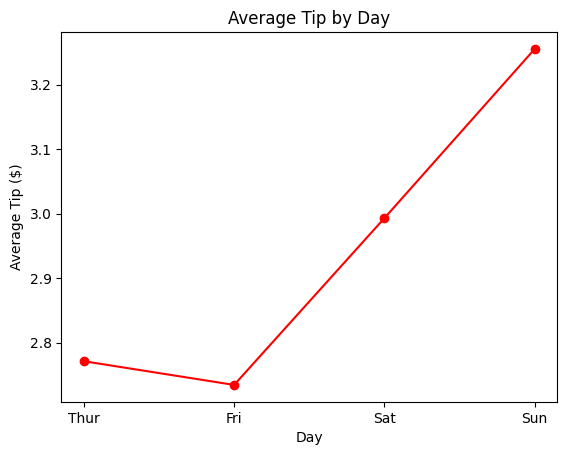

In [195]:
plt.plot(daily_tip.index, daily_tip.values, marker="o", color = "red")
plt.title("Average Tip by Day")
plt.xlabel("Day")
plt.ylabel("Average Tip ($)")
plt.show()

<div dir="rtl"><font color="#9e0059" face="B Titr">

###  Bar Chart

</div>

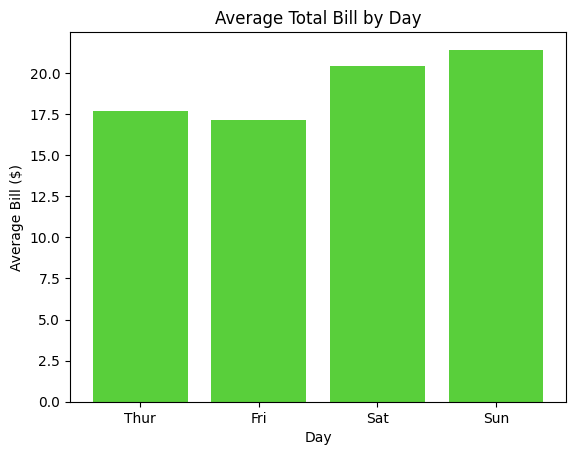

In [196]:
daily_bill = df.groupby("day", observed=True)["total_bill"].mean()

plt.bar(daily_bill.index, daily_bill.values, color="#59cf3b")
plt.title("Average Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Average Bill ($)")
plt.show()

<div dir="rtl"><font color="#9e0059" face="B Titr">

###  Scatter Plot

</div>

In [197]:
df[["total_bill", "tip"]].corr()

,total_bill,tip
total_bill,1.000000,0.675734
tip,0.675734,1.000000


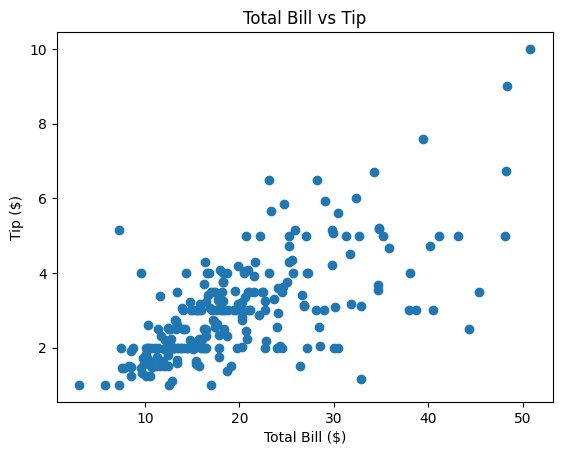

In [198]:
plt.scatter(df["total_bill"], df["tip"])
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.show()

<div dir="rtl"><font color="#9e0059" face="B Titr">

###  Heatmap

</div>

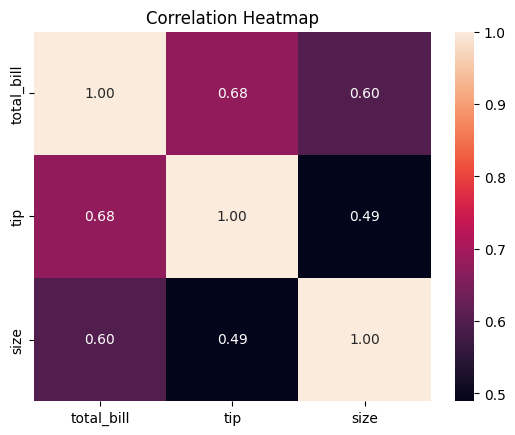

In [199]:
corr = df[["total_bill", "tip", "size"]].corr()

sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

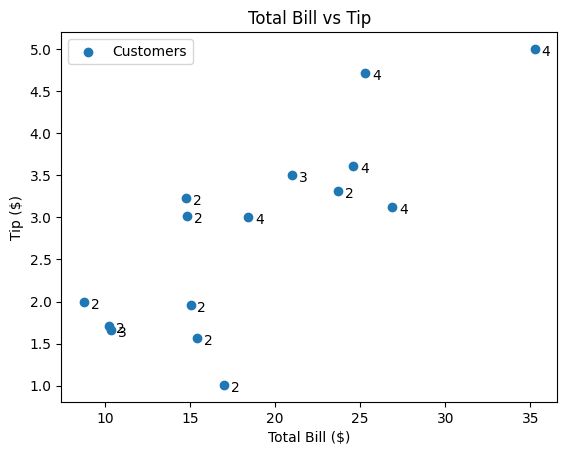

In [200]:
sample = df.head(15)

plt.scatter(sample["total_bill"], sample["tip"], label="Customers")

for size, bill, tip in zip(sample["size"], sample["total_bill"], sample["tip"]):
    plt.annotate(
        size,
        xy=(bill, tip),
        xytext=(5, -5),
        textcoords="offset points"
    )

plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.legend()
plt.show()

<div dir="rtl"><font color="#9e0059" face="B Titr">

###  Histogram

</div>

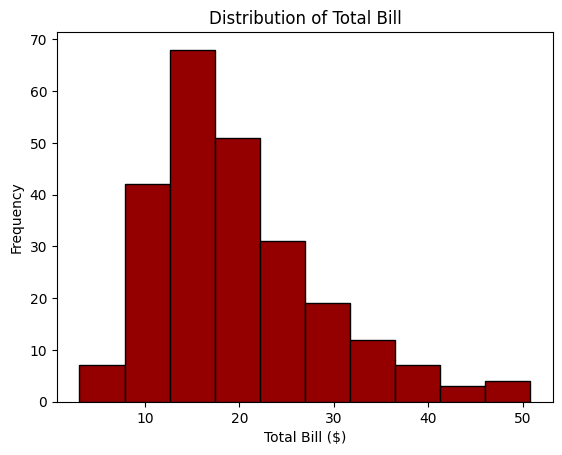

In [201]:
plt.hist(df["total_bill"], bins=10, edgecolor="black", color="#940000")
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Frequency")
plt.show()



<div dir="rtl"><font color="#9e0059" face="B Titr">

###  Pie Charts

</div>

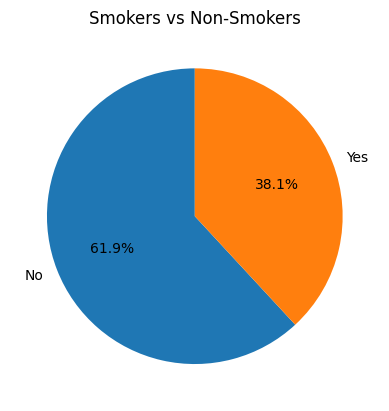

In [202]:
smoker_counts = df["smoker"].value_counts()

plt.pie(
    smoker_counts,
    labels=smoker_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Smokers vs Non-Smokers")
plt.show()

<div dir="rtl"><font color="#9e0059" face="B Titr">

###  Subplot

</div>

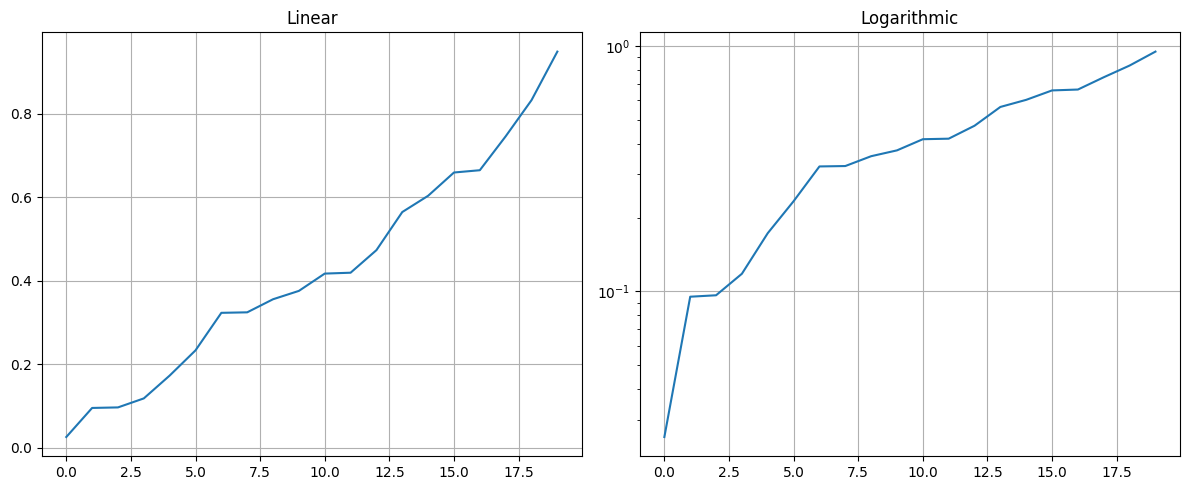

In [203]:
y = np.random.randn(50)
y = y[(y > 0) & (y < 1)]
y.sort()
x = np.arange(len(y))


plt.figure(figsize=(12, 5)) # (width, height)

plt.subplot(1, 2, 1) # (nrow,ncol,index)
plt.plot(x, y)
plt.yscale("linear")
plt.title("Linear")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x, y)
plt.yscale("log")
plt.title("Logarithmic")
plt.grid(True)

plt.tight_layout()
plt.show()

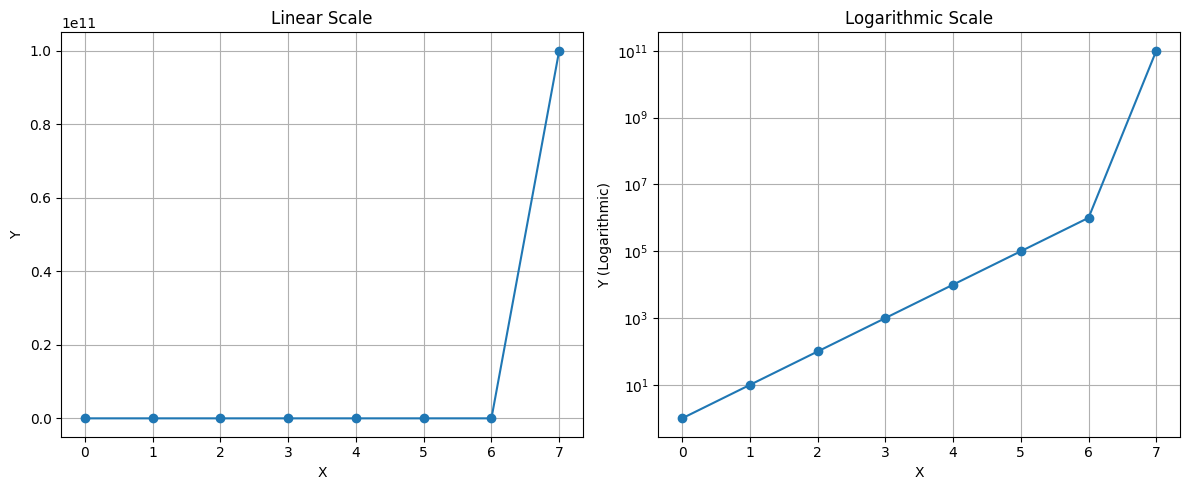

In [204]:
y = np.array([1, 10, 100, 1000, 10000, 100000, 1000000, 100000000000])
x = np.arange(len(y))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(x, y, marker="o")
plt.yscale("linear")
plt.title("Linear Scale")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.subplot(1, 2, 2)

plt.plot(x, y, marker="o")
plt.yscale("log")
plt.title("Logarithmic Scale")
plt.xlabel("X")
plt.ylabel("Y (Logarithmic)")
plt.grid(True)

plt.tight_layout()
plt.show()

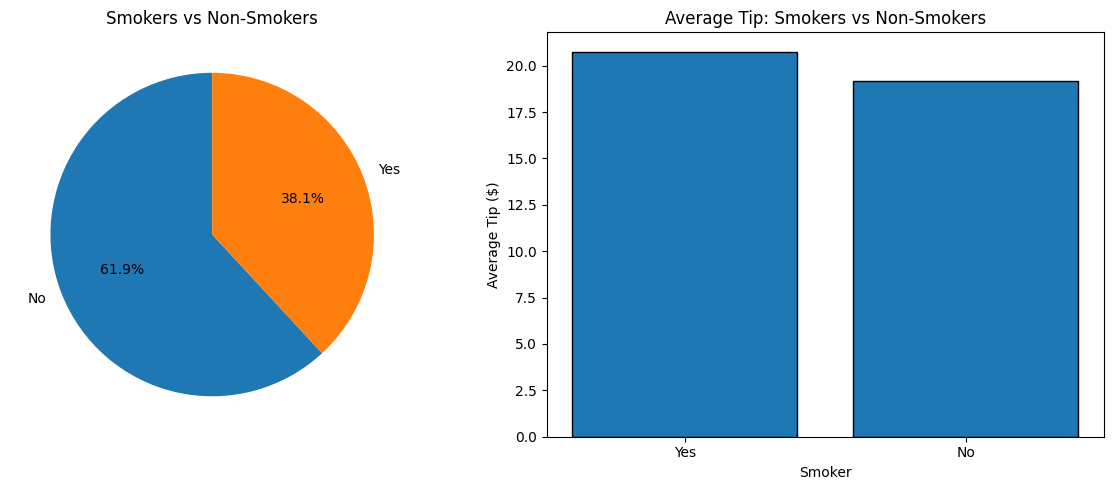

In [205]:
smoker_counts = df["smoker"].value_counts()

plt.figure(figsize=(12, 5)) # (width, height)

plt.subplot(1, 2, 1) # (nrow,ncol,index)
plt.pie(
    smoker_counts,
    labels=smoker_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Smokers vs Non-Smokers")

plt.subplot(1, 2, 2)
avg_tip = df.groupby("smoker", observed=True)["total_bill"].mean()
plt.bar(
    avg_tip.index,
    avg_tip.values,
    edgecolor="black"
)

plt.title("Average Tip: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Average Tip ($)")

plt.tight_layout()
plt.show()

<div dir="rtl"><font color="#9e0059" face="B Titr">

# منابع 

</div>

* Grus, J. (2019). Data Science from Scratch: First Principles with Python. Japan: O'Reilly Media.
* McKinney, W. (2013). Python for Data Analysis. Germany: O'Reilly Media, Incorporated.

* https://www.kaggle.com/datasets/ranjeetjain3/seaborn-tips-dataset
* https://www.geeksforgeeks.org/python/matplotlib-tutorial/
* https://www.geeksforgeeks.org/pandas/pandas-tutorial/